<div style="background:linear-gradient(120deg,#0B2545,#134074 55%,#3C6E71);color:#fff;padding:28px 30px;border-radius:12px;margin:8px 0 18px">
  <div style="font-size:13px;letter-spacing:2px;opacity:.88">PHY-3202 · PROJET 1 · NOTEBOOK 00</div>
  <h1 style="color:#fff;margin:10px 0;font-size:30px">Fondations probabilistes</h1>
  <div style="font-size:17px">D'une série temporelle à un vecteur de fréquences</div>
</div>

**Alex Baker · Université Laval · Automne 2026**

> **Question de départ :** quels choix faut-il faire pour transformer des observations numériques en un vecteur de probabilités estimées ?

Ce carnet est une étape préparatoire à `01_laboratoire.ipynb`. Son résultat est le vecteur
$\hat{\mathbf p}$, **sans calcul d'entropie**. Il utilise une partition d'amplitude comme
premier exemple concret, sans supposer que cette représentation conviendra à toutes les
questions sur le réseau électrique.

**Mode de lecture.** Les sections 1 à 5 construisent une représentation sur douze valeurs
que tu peux vérifier avec un crayon. La section 6 utilise des données simulées pour
étudier la précision de cette représentation lorsque le nombre de valeurs change.
Chaque expérience indique ce qui est fixé, ce qui varie et ce qu'on peut conclure.


<a id="sommaire"></a>
## Parcours

1. [La question et les deux discrétisations](#question)
2. [Un exemple vérifiable à la main](#main)
3. [Reproduire les comptages en Python](#python)
4. [Changer uniquement la partition](#partition)
5. [Ce que la représentation oublie](#ordre)
6. [Changer la taille de l'échantillon](#taille)
7. [Bilan et questions à documenter](#bilan)
8. [Lectures ciblées](#lectures)

<a id="question"></a>
## 1 · Quelle transformation étudie-t-on ?

Une fonction continue $x(t)$ peut être observée aux instants $t_1,\ldots,t_N$ :

$$x(t)\;\longrightarrow\; (x_1,\ldots,x_N), \qquad x_k=x(t_k).$$

C'est **l'échantillonnage temporel** : la fonction peut être définie à tout instant,
mais le tableau de données ne contient que les valeurs relevées aux instants choisis.
Une mesure réelle peut elle aussi arriver directement sous forme de points $(t_k,x_k)$ :
il n'est pas nécessaire qu'on connaisse une formule pour $x(t)$.

**Attention aux deux axes :** choisir les instants $t_k$ détermine *quand* on observe;
choisir les états $S_i$ plus bas détermine *quelles amplitudes* on regroupe. Ajouter
des points dans le temps (changer $N$) et découper plus finement les amplitudes
(changer $K$) sont deux décisions différentes.

On fait ensuite un **autre choix**, distinct : regrouper les amplitudes dans des états
$S_1,\ldots,S_K$. Chaque observation appartient à un et un seul état. On compte alors
$n_i$ observations dans $S_i$ et on calcule

$$\hat p_i=\frac{n_i}{N}, \qquad
\hat{\mathbf p}=(\hat p_1,\ldots,\hat p_K).$$

**Que veut dire « probabilité » ici ?** Après avoir choisi une observation au hasard
parmi les $N$ instants enregistrés, $\hat p_i=n_i/N$ est la fraction de ces instants
pour laquelle la valeur appartient à $S_i$. Cette fréquence décrit les données
observées. Si un procédé sous-jacent a une probabilité théorique $p_i$, nous ne la
connaissons généralement pas : le chapeau dans $\hat p_i$ signifie « estimée ».
Même pour un signal déterministe comme un sinus, la fraction des instants observés
dans une plage d'amplitudes a un sens. Elle dépend alors des instants choisis;
elle n'est pas une prédiction automatique de la prochaine valeur.

**Rôle des lettres.** $N$ = nombre de valeurs observées; $K$ = nombre d'états;
$n_i$ = nombre de valeurs tombées dans le $i$-ième état. On doit retrouver
$\sum_i n_i=N$ et $\sum_i\hat p_i=1$, puisque chaque valeur est comptée une seule fois.

<div style="background:#eaf2f5;border-left:5px solid #3C6E71;padding:12px 16px;border-radius:6px;color:#163541">
<b>Question à garder ouverte :</b> faut-il regrouper les valeurs par amplitude, par variations,
ou selon des motifs successifs ? Ici, on étudie <b>une seule construction</b> à la fois.
</div>


<a id="main"></a>
## 2 · Faire le premier calcul à la main

Prenons les 12 observations suivantes, dans cet ordre :

$$x=(-0.90,-0.40,-0.20,0.10,0.20,0.30,0.55,0.62,0.71,0.80,0.90,0.98).$$

**Choix explicite :** domaine $[-1,1]$, partagé en $K=4$ intervalles de largeur $0.5$.
Une frontière intérieure appartient à l'intervalle de droite ; la borne $1$ est incluse
dans le dernier. Ainsi, une observation égale à $0$ irait dans $S_3$.

| État | Intervalle | Valeurs observées | Compte $n_i$ | Fréquence $\hat p_i$ |
|:--|:--|:--|--:|--:|
| $S_1$ | $[-1,-0.5)$ | $-0.90$ | 1 | $1/12$ |
| $S_2$ | $[-0.5,0)$ | $-0.40,-0.20$ | 2 | $2/12$ |
| $S_3$ | $[0,0.5)$ | $0.10,0.20,0.30$ | 3 | $3/12$ |
| $S_4$ | $[0.5,1]$ | $0.55,0.62,0.71,0.80,0.90,0.98$ | 6 | $6/12$ |

**Avant de lancer Python :** vérifier $1+2+3+6=12$ et prédire le vecteur :

$$\boxed{\hat{\mathbf p}=\left(\tfrac1{12},\tfrac2{12},\tfrac3{12},\tfrac6{12}\right).}$$

Un état qui ne reçoit aucune observation garderait sa place dans le vecteur, avec fréquence $0$.

**Suivons une valeur concrète :** $x_1=-0.90$ tombe entre $-1$ et $-0.5$,
donc dans $S_1$. À l'inverse, $x_{12}=0.98$ est dans $S_4$. Le symbole $S_i$
désigne une *catégorie*, alors que $n_i$ indique combien de valeurs y sont rangées.
Ici $n_4=6$ signifie « six des douze valeurs sont entre $0.5$ et $1$ »;
$\hat p_4=6/12=0.5$ signifie « la moitié des observations sont dans cette plage ».

La partition couvre tout le domaine choisi, sans chevauchement. Notre convention
pour les bornes évite qu'une valeur exactement égale à $0$ soit comptée deux fois.
L'intervalle $[-1,1]$ est **un choix de l'expérience**, et non une propriété imposée
par les données : sur une mesure du réseau, il faudrait préciser unités et bornes.


<a id="python"></a>
## 3 · Reproduire exactement les quatre opérations

**À observer dans les prochaines cellules :** les frontières sont fixées *avant* les comptes.
Le programme indique l'état de chaque observation, puis compte et divise par $N$.

Les trois prochaines cellules correspondent aux trois lignes du tableau précédent :
**(1)** créer les valeurs et les bornes; **(2)** écrire pour chaque valeur son état;
**(3)** compter chaque état et diviser par $N$. Regarde les sorties entre les cellules :
elles rendent visibles des opérations que `np.histogram` ferait d'un seul coup.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Les données sont écrites explicitement pour retrouver le tableau de la section 2.
x = np.array([-0.90, -0.40, -0.20, 0.10, 0.20, 0.30,
              0.55, 0.62, 0.71, 0.80, 0.90, 0.98])
# Cinq bornes délimitent quatre intervalles : K = len(bornes) - 1.
bornes = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
# N vient des observations, et non du nombre de bornes.
N = len(x)
K = len(bornes) - 1

print(f"Nombre d'observations N = {N}; nombre d'états K = {K}")
print("Bornes de la partition :", bornes)


Nombre d'observations N = 12; nombre d'états K = 4
Bornes de la partition : [-1.  -0.5  0.   0.5  1. ]


In [8]:
# On fait d'abord les affectations une observation à la fois.
etats = []  # Les indices 0, 1, 2, 3 correspondent aux états S_1, ..., S_4.
for valeur in x:
    if not bornes[0] <= valeur <= bornes[-1]:
        raise ValueError(f"Observation hors du domaine fixé : {valeur}")
    # Parcourir les intervalles jusqu'à trouver celui qui contient cette valeur.
    for i in range(K):
        dans_intervalle = bornes[i] <= valeur < bornes[i + 1]
        # Exception : seule la borne finale +1 appartient au dernier intervalle.
        derniere_borne = i == K - 1 and valeur == bornes[-1]
        if dans_intervalle or derniere_borne:
            # En Python, l'indice commence à 0 : i=0 désigne S_1.
            etats.append(i)
            break  # Une observation ne doit appartenir qu'à un seul état.

for numero, (valeur, etat) in enumerate(zip(x, etats), start=1):
    print(f"Observation {numero:2d} : {valeur:5.2f} → S_{etat + 1}")


Observation  1 : -0.90 → S_1
Observation  2 : -0.40 → S_2
Observation  3 : -0.20 → S_2
Observation  4 :  0.10 → S_3
Observation  5 :  0.20 → S_3
Observation  6 :  0.30 → S_3
Observation  7 :  0.55 → S_4
Observation  8 :  0.62 → S_4
Observation  9 :  0.71 → S_4
Observation 10 :  0.80 → S_4
Observation 11 :  0.90 → S_4
Observation 12 :  0.98 → S_4


In [9]:
# `count(i)` retrouve le nombre n_i pour chacun des K états, même vide.
comptes = np.array([etats.count(i) for i in range(K)])
# Chaque fréquence est un compte divisé par le même total N.
p_estime = comptes / N

print("Comptages n  =", comptes)
print("Fréquences p̂ =", np.round(p_estime, 4))
print("Somme des comptes =", comptes.sum())
print("Somme des fréquences =", p_estime.sum())

# Les assertions rendent visibles les trois vérifications du calcul manuel.
assert comptes.tolist() == [1, 2, 3, 6]
assert comptes.sum() == N
assert np.isclose(p_estime.sum(), 1.0)


Comptages n  = [1 2 3 6]
Fréquences p̂ = [0.0833 0.1667 0.25   0.5   ]
Somme des comptes = 12
Somme des fréquences = 1.0


### Voir les données et leur regroupement

Le graphique de gauche conserve l'ordre des observations. Celui de droite montre les fréquences
des quatre intervalles. La hauteur d'une barre est une **fréquence**, pas une densité : toutes
les barres de ce premier exemple ont la même largeur.

**Comment lire les deux panneaux :** un point à gauche est une observation $x_k$
à sa position $k$ dans la série; les lignes pointillées matérialisent les frontières
entre états. Une barre à droite regroupe plusieurs de ces points et mesure $n_i/N$.
On voit donc où se trouve la perte d'information : la barre conserve le nombre
de valeurs par état, mais ne révèle pas *quand* elles ont été observées.


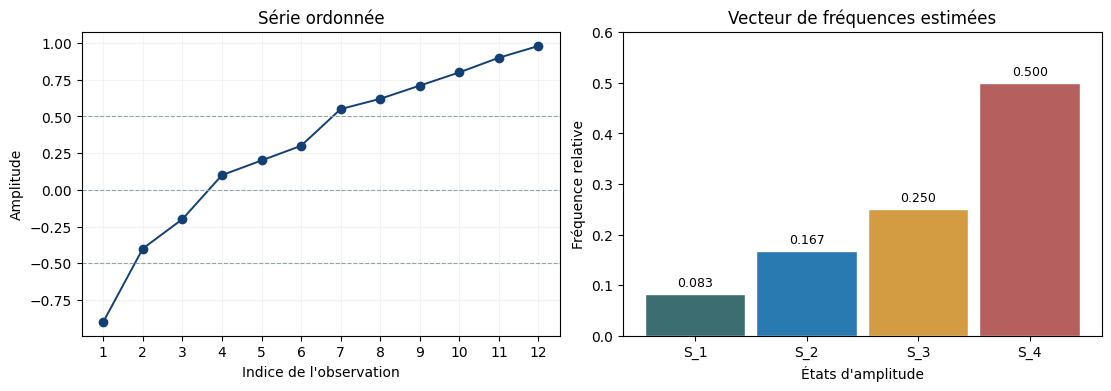

In [10]:
# Deux vues des mêmes douze nombres : l'une conserve leur ordre, l'autre les regroupe.
fig, (ax_t, ax_p) = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
couleurs = ["#3C6E71", "#287AB0", "#D39C43", "#B65F5F"]
# `np.arange(1, N+1)` produit les indices 1, 2, ..., N.
ax_t.plot(np.arange(1, N + 1), x, "o-", color="#134074", linewidth=1.4)
for valeur_borne in bornes[1:-1]:
    ax_t.axhline(valeur_borne, color="#91a4ae", linestyle="--", linewidth=0.8)
ax_t.set(xlabel="Indice de l'observation", ylabel="Amplitude", title="Série ordonnée")
ax_t.set_xticks(np.arange(1, N + 1))
ax_t.grid(alpha=0.15)

# Placer une barre au centre de chaque intervalle (les centres ne sont pas des données).
centres = (bornes[:-1] + bornes[1:]) / 2
# La hauteur représente n_i/N; les quatre hauteurs totalisent 1.
ax_p.bar(centres, p_estime, width=np.diff(bornes) * 0.9,
         color=couleurs, edgecolor="white")
ax_p.set_xticks(centres, [f"S_{i + 1}" for i in range(K)])
ax_p.set(xlabel="États d'amplitude", ylabel="Fréquence relative",
         title="Vecteur de fréquences estimées", ylim=(0, 0.60))
for centre, frequence in zip(centres, p_estime):
    ax_p.text(centre, frequence + 0.015, f"{frequence:.3f}", ha="center", fontsize=9)
plt.show()


<a id="partition"></a>
## 4 · Changer une seule décision : le nombre d'états

Nous ne changeons **ni les douze observations ni le domaine $[-1,1]$**.
Avec $K=2$, les états sont $[-1,0)$ et $[0,1]$ : les trois valeurs négatives
vont à gauche et les neuf autres à droite, d'où $(3/12,9/12)$.
Avec $K=4$, on retrouve $(1/12,2/12,3/12,6/12)$. Avec $K=8$, certains états
peuvent être vides : ils doivent tout de même apparaître dans le vecteur.
Le même numéro $S_1$ ne recouvre plus la même plage lorsque $K$ change.

**Prédiction avant exécution :** on garde exactement les mêmes 12 nombres et le même domaine
$[-1,1]$. Si on choisit $K=2$ et la frontière $0$, quels sont les deux comptes ?
Le vecteur à deux composantes peut-il être comparé composante par composante à celui à quatre ?

Cette fonction regroupe les opérations déjà réalisées. Elle conserve **tous les états**,
même ceux dont le compte est nul, et signale une valeur hors du domaine fixé.


In [11]:
def frequences_par_amplitude(observations, bornes):
    '''Affecte chaque amplitude à un intervalle, puis estime ses fréquences.

    Intervalles [a,b), sauf le dernier [a,b]. Chaque observation est comptée une fois.
    Retourne (indices_des_états, comptes, fréquences).
    '''
    # Accepter aussi une liste Python, tout en calculant sur des tableaux de nombres.
    observations = np.asarray(observations, dtype=float)
    bornes = np.asarray(bornes, dtype=float)
    # Une série vide ou non numérique ne permettrait pas de diviser par N.
    if observations.ndim != 1 or len(observations) == 0 or not np.all(np.isfinite(observations)):
        raise ValueError("Il faut une série non vide d'observations finies.")
    if bornes.ndim != 1 or len(bornes) < 2 or not np.all(np.isfinite(bornes)):
        raise ValueError("Il faut au moins deux bornes finies.")
    # Des frontières désordonnées ou répétées ne forment pas la partition prévue.
    if not np.all(np.diff(bornes) > 0):
        raise ValueError("Les bornes doivent être strictement croissantes.")
    if np.any(observations < bornes[0]) or np.any(observations > bornes[-1]):
        raise ValueError("Une observation est hors du domaine de la partition.")

    # Première sortie : un indice d'état par observation, dans le même ordre.
    etats = []
    for valeur in observations:
        for i in range(len(bornes) - 1):
            dans_intervalle = bornes[i] <= valeur < bornes[i + 1]
            derniere_borne = i == len(bornes) - 2 and valeur == bornes[-1]
            if dans_intervalle or derniere_borne:
                etats.append(i)
                break

    # Deuxième sortie : les comptes, zéros inclus. Troisième : les fréquences.
    comptes = np.array([etats.count(i) for i in range(len(bornes) - 1)])
    return np.array(etats), comptes, comptes / len(observations)


# Une seule décision change entre les trois essais : le nombre d'états K.
for K_essai in (2, 4, 8):
    # K+1 bornes équidistantes délimitent K états sur le même domaine.
    bornes_essai = np.linspace(-1, 1, K_essai + 1)
    _, comptes_essai, p_essai = frequences_par_amplitude(x, bornes_essai)
    print(f"K={K_essai:2d} | comptes={comptes_essai.tolist()} | ",
          f"fréquences={np.round(p_essai, 3).tolist()}")

assert frequences_par_amplitude(x, np.array([-1, 0, 1]))[1].tolist() == [3, 9]
assert frequences_par_amplitude(x, bornes)[1].tolist() == [1, 2, 3, 6]


K= 2 | comptes=[3, 9] |  fréquences=[0.25, 0.75]
K= 4 | comptes=[1, 2, 3, 6] |  fréquences=[0.083, 0.167, 0.25, 0.5]
K= 8 | comptes=[1, 0, 1, 1, 2, 1, 3, 3] |  fréquences=[0.083, 0.0, 0.083, 0.083, 0.167, 0.083, 0.25, 0.25]


**Mes observations :**

Avec $K=2$, le premier état $[-1,0)$ contient $-0,90$, $-0,40$ et $-0,20$, soit 3 observations. Le second état $[0,1]$ contient les 9 autres. Le vecteur de fréquences est donc (3/12,9/12)=(0,25,0,75).

Avec $K=8$, chacun des quatre intervalles précédents est coupé en deux. Les comptes deviennent $(1,0,1,1,2,1,3,3)$. Le deuxième état, $[-0,75,-0,5)$, est vide : aucune de nos 12 valeurs n’y tombe. Cela ne signifie pas qu’une valeur dans cet intervalle serait impossible.

Nous gardons le domaine $[-1,1]$ fixe pour que **seul le nombre d’intervalles $K$** change. Si nous modifiions aussi les bornes du domaine, nous ne pourrions plus attribuer les changements du vecteur au seul découpage. La même série peut donc produire des vecteurs différents selon la partition choisie.


<a id="ordre"></a>
## 5 · Qu'a-t-on perdu ?

Cette représentation compte les amplitudes dans chaque état. Que se passerait-il si on
mélangeait **les mêmes observations** dans un autre ordre ? Fais la prédiction avant
l'exécution. Utilise une graine fixée pour retrouver exactement le même mélange.

Par exemple, la suite $(0.10,0.20,0.30)$ monte régulièrement, mais la suite
$(0.30,0.10,0.20)$ emploie les mêmes trois valeurs dans un autre ordre.
Une représentation qui ne compte que des plages d'amplitude leur donne les mêmes
comptes. Le test ci-dessous fait cette permutation sur toute notre série.


Série d'origine : [-0.9  -0.4  -0.2   0.1   0.2   0.3   0.55  0.62  0.71  0.8   0.9   0.98]
Série mélangée  : [ 0.55 -0.4   0.8   0.71  0.98 -0.9  -0.2   0.1   0.3   0.62  0.2   0.9 ]
Comptes identiques ? True
Vecteurs identiques ? True


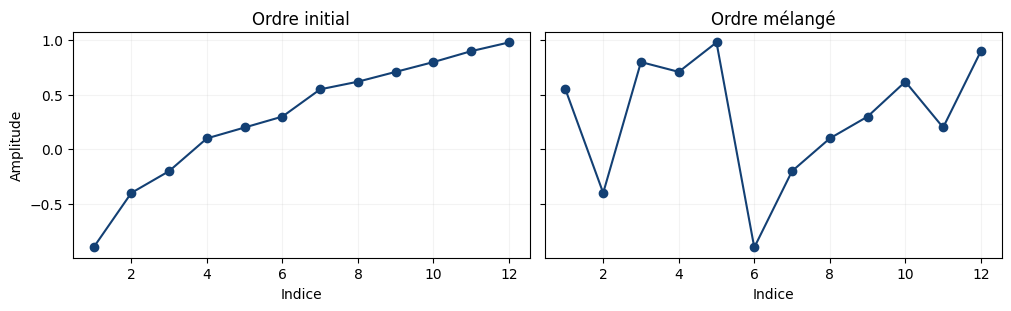

In [12]:
# Fixer la graine rend l'ordre mélangé reproductible lors d'une nouvelle exécution.
rng = np.random.default_rng(2026)
# `permutation` change les positions, sans ajouter ni supprimer de valeur.
x_melange = rng.permutation(x)
_, comptes_melanges, p_melange = frequences_par_amplitude(x_melange, bornes)

print("Série d'origine :", x)
print("Série mélangée  :", x_melange)
print("Comptes identiques ?", np.array_equal(comptes, comptes_melanges))
print("Vecteurs identiques ?", np.array_equal(p_estime, p_melange))

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True, layout="constrained")
for ax, serie, titre in zip(axes, [x, x_melange], ["Ordre initial", "Ordre mélangé"]):
    ax.plot(np.arange(1, N + 1), serie, "o-", color="#134074")
    ax.set(xlabel="Indice", title=titre)
    ax.grid(alpha=0.15)
axes[0].set_ylabel("Amplitude")
plt.show()

# Les assertions vérifient exactement la conséquence attendue de la permutation.
assert np.array_equal(comptes, comptes_melanges)
assert np.array_equal(p_estime, p_melange)


**Interprétation :** le mélange conserve chaque valeur et, par conséquent, chaque compte
d'amplitude. Le vecteur $\hat{\mathbf p}$ construit ici oublie l'ordre temporel.
Cette observation concerne **cette représentation par intervalles d'amplitude** : une autre
définition des états pourrait tenir compte de l'ordre.

*Avec mes mots :* …

**Ce que le test démontre exactement :** le vecteur d'amplitudes est inchangé par
toute permutation des douze observations, parce que chaque valeur reste dans son
intervalle. Il ne faut donc pas lire la forme temporelle, la périodicité ou la
présence de cascades dans ce seul vecteur. Une mesure fondée sur l'ordre des
valeurs demanderait d'autres événements; ce sera une question distincte.


<a id="taille"></a>
## 6 · Changer la taille de l'échantillon

Les sections précédentes gardaient les mêmes 12 observations. On fait maintenant varier $N$
en laissant la partition **identique**, pour isoler l'effet de la quantité de données.

Douze valeurs fixes ne suffisent pas : il faut une source capable d'en produire autant qu'on
veut. On tire donc des observations d'une loi **uniforme sur $[-1,1]$**, dont on connaît la
réponse exacte. Avec $K=4$ intervalles de largeur égale, chaque état couvre un quart du
domaine, donc

$$\mathbf p_{\text{vrai}}=(0.25,\;0.25,\;0.25,\;0.25).$$

L'uniforme est choisi pour une raison précise : chaque plage de largeur $0.5$ occupe
$1/4$ de l'intervalle de longueur $2$, donc sa probabilité théorique vaut $0.25$.
Cette fois, les tirages sont aléatoires et indépendants. Deux échantillons de taille
$N=12$ peuvent donner des vecteurs différents, même si leur loi théorique est
exactement la même. Disposer de la vraie valeur permet de mesurer l'écart de
$\hat{\mathbf p}$ à $\mathbf p$. Dans des données réelles, $\mathbf p$ est en
général inconnu et cette comparaison directe n'est pas possible.

<div style="background:#fff5e9;border-left:5px solid #D39C43;padding:12px 16px;border-radius:6px;color:#49321e">
<b>Pourquoi pas un sinus échantillonné ?</b> Un sinus de période 50 évalué aux instants
entiers ne visite que 50 phases avant de répéter le même cycle (certaines amplitudes
peuvent même coïncider). Augmenter $N$ n'ajoute
alors aucune observation nouvelle : les comptes se contentent de se multiplier et les
fréquences se figent. Le vecteur converge alors correctement vers les fréquences de ces phases répétées,
mais des cycles supplémentaires aux mêmes phases n'apportent pas de nouvelles
amplitudes pour étudier la précision de l'estimation d'une distribution continue.
</div>

**Prédictions à écrire avant d'exécuter :**

- Pour $N=12$, le vecteur doit-il être exactement $(0.25,0.25,0.25,0.25)$ ? Pourquoi ?
- Pour $N=100\,000$ ?
- Si on multiplie $N$ par $100$, par combien l'erreur devrait-elle être divisée ?


### 6.1 · Une version vectorisée, validée sur le cas connu

La fonction écrite à la main parcourt les observations une à une, ce qui convient pour 12
valeurs mais devient trop lent pour $10^5$. NumPy fournit `np.histogram`, qui applique
exactement la même convention : intervalles $[a,b)$, dernier intervalle fermé $[a,b]$.

On ne la substitue pas sur parole — on vérifie d'abord qu'elle reproduit les comptes établis
à la main, puis on s'en sert pour les grands échantillons.

La fonction rend deux résultats : **comptes** et **comptes divisés par $N$**.
Il faut laisser `density=False`, la valeur par défaut, car `density=True`
renverrait des hauteurs de *densité* plutôt que les comptes $n_i$. Les trois
partitions déjà étudiées servent ici de contrôle : mêmes données et mêmes bornes
doivent produire les mêmes résultats avec les deux implémentations.


In [13]:
def frequences_rapides(observations, bornes):
    """Équivalent vectorisé de `frequences_par_amplitude`, comptes et fréquences seulement."""
    # La même partition doit couvrir toutes les valeurs de l'échantillon.
    observations = np.asarray(observations, dtype=float)
    bornes = np.asarray(bornes, dtype=float)
    if np.any(observations < bornes[0]) or np.any(observations > bornes[-1]):
        raise ValueError("Une observation est hors du domaine de la partition.")
    # `bins=bornes` impose nos frontières; le résultat est un compte par état.
    comptes, _ = np.histogram(observations, bins=bornes)
    # Le vecteur de fréquences conserve même les états dont le compte vaut zéro.
    return comptes, comptes / observations.size


# Validation : les deux fonctions doivent coïncider sur les cas déjà vérifiés à la main.
for bornes_test in (bornes, np.array([-1.0, 0.0, 1.0]), np.linspace(-1, 1, 9)):
    _, comptes_lents, p_lentes = frequences_par_amplitude(x, bornes_test)
    comptes_rapides, p_rapides = frequences_rapides(x, bornes_test)
    assert np.array_equal(comptes_lents, comptes_rapides)
    assert np.allclose(p_lentes, p_rapides)
    print(f"K={len(bornes_test) - 1:2d} | à la main {comptes_lents.tolist()}"
          f" | np.histogram {comptes_rapides.tolist()}  ✓")

print("\nLes deux implémentations donnent les mêmes comptes : on peut utiliser la rapide.")


K= 4 | à la main [1, 2, 3, 6] | np.histogram [1, 2, 3, 6]  ✓
K= 2 | à la main [3, 9] | np.histogram [3, 9]  ✓
K= 8 | à la main [1, 0, 1, 1, 2, 1, 3, 3] | np.histogram [1, 0, 1, 1, 2, 1, 3, 3]  ✓

Les deux implémentations donnent les mêmes comptes : on peut utiliser la rapide.


### 6.2 · Le vecteur estimé quand $N$ augmente

Partition fixée à $K=4$ sur $[-1,1]$. Seul $N$ change. La dernière colonne donne l'écart
total à la vraie distribution,

$$D(\hat{\mathbf p},\mathbf p)=\sum_{i=1}^{K}\bigl|\hat p_i-p_i\bigr|.$$

On additionne les écarts absolus de toutes les composantes; pour $K=4$,
$D=0$ signifie une coïncidence exacte avec $(0.25,0.25,0.25,0.25)$.
Cette distance peut aller jusqu'à $1.5$ ici : si les douze points tombaient
dans un seul des quatre états, l'écart serait $0.75+3(0.25)=1.5$.
Elle sert à rendre l'erreur visible dans cette simulation, **pas** à décider
si une mesure du réseau révèle une instabilité.

La cellule suivante fait **un tirage différent pour chaque $N$**. Une ligne
isolée peut être moins proche de la vérité que la ligne précédente par hasard;
il faut regarder la tendance et répéter l'expérience avant d'en tirer une loi.


In [14]:
# Graine fixée : les nombres du tableau sont reproductibles.
rng = np.random.default_rng(20260923)
bornes_4 = np.linspace(-1, 1, 5)
# Théorie connue uniquement parce que le générateur est uniforme et les bins égaux.
p_vrai = np.full(4, 0.25)

print(f"{'N':>7} | {'p̂ (4 états)':^34} | {'états vides':>11} | {'écart D':>8}")
print("-" * 70)
for N_essai in (12, 50, 200, 1_000, 10_000, 100_000):
    # Chaque boucle tire un nouvel échantillon; ce n'est pas la répétition des 12 points.
    echantillon_uniforme = rng.uniform(-1.0, 1.0, N_essai)
    comptes_N, p_N = frequences_rapides(echantillon_uniforme, bornes_4)
    # Additionner les quatre différences absolues au vecteur théorique.
    ecart = np.abs(p_N - p_vrai).sum()
    valeurs = " ".join(f"{valeur:7.4f}" for valeur in p_N)
    print(f"{N_essai:7d} | {valeurs} | {int((comptes_N == 0).sum()):11d} | {ecart:8.4f}")


      N |            p̂ (4 états)            | états vides |  écart D
----------------------------------------------------------------------
     12 |  0.3333  0.1667  0.1667  0.3333 |           0 |   0.3333
     50 |  0.1400  0.3800  0.2400  0.2400 |           0 |   0.2600
    200 |  0.2550  0.2450  0.2200  0.2800 |           0 |   0.0700
   1000 |  0.2380  0.2580  0.2610  0.2430 |           0 |   0.0380
  10000 |  0.2445  0.2531  0.2501  0.2523 |           0 |   0.0110
 100000 |  0.2486  0.2504  0.2485  0.2526 |           0 |   0.0059


### 6.3 · À quelle vitesse l'erreur diminue-t-elle ?

Un seul tirage par valeur de $N$ reste bruité : l'écart mesuré dépend du hasard de ce tirage
précis. On répète donc l'expérience et on moyenne, puis on trace en échelle logarithmique.

**Pourquoi répéter ?** Pour un état de probabilité $p_i$, la fréquence d'un tirage
indépendant fluctue typiquement sur une échelle proportionnelle à
$\sqrt{p_i(1-p_i)/N}$. Avec la même partition et des tirages indépendants,
une erreur moyenne comme $D$ est donc attendue de l'ordre de $N^{-1/2}$.
Ce n'est **ni** une garantie pour chaque tirage, **ni** une formule universelle
pour une série temporelle corrélée. Le bruit brun, par exemple, demande une
analyse de dépendance avant de traiter ses observations comme indépendantes.

**Prédiction :** si l'erreur moyenne suit cette tendance dans *notre expérience
uniforme*, le graphique de $\log D$ selon $\log N$ a une pente voisine de
$-0.5$. Multiplier $N$ par $100$ devrait alors diviser l'erreur typique
par environ $10$.


Pente ajustée : -0.499   (valeur attendue : -0.5)
Erreur à N=12 : 0.3950
Erreur à N=100000 : 0.00421
Rapport observé : 93.9×   pour un rapport de N de 8333×


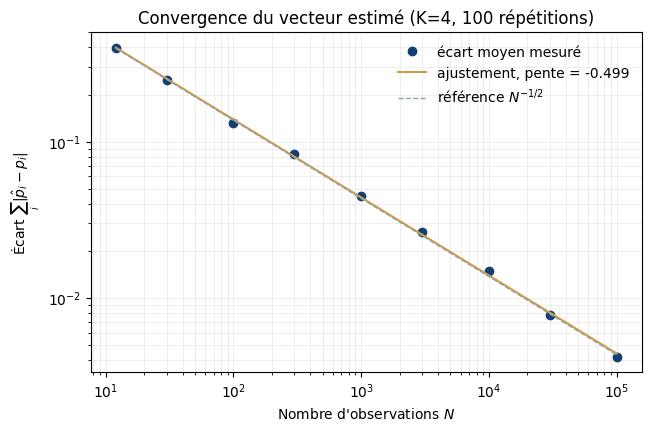

In [15]:
N_liste = np.array([12, 30, 100, 300, 1_000, 3_000, 10_000, 30_000, 100_000])
# Refaire 100 tirages indépendants à chaque taille limite la fluctuation de la courbe.
N_REPETITIONS = 100
rng = np.random.default_rng(20260924)

ecarts_moyens = []
for N_essai in N_liste:
    ecarts = []
    for _ in range(N_REPETITIONS):
        # Nouveau tirage de taille N_essai; la partition bornes_4 reste fixée.
        _, p_N = frequences_rapides(rng.uniform(-1.0, 1.0, int(N_essai)), bornes_4)
        ecarts.append(np.abs(p_N - p_vrai).sum())
    # Moyenne des 100 écarts pour cette taille, avant de passer au N suivant.
    ecarts_moyens.append(np.mean(ecarts))
ecarts_moyens = np.array(ecarts_moyens)

# Ajuster log(erreur moyenne) = pente * log(N) + constante.
pente, ordonnee = np.polyfit(np.log(N_liste), np.log(ecarts_moyens), deg=1)
print(f"Pente ajustée : {pente:.3f}   (valeur attendue : -0.5)")
print(f"Erreur à N={N_liste[0]} : {ecarts_moyens[0]:.4f}")
print(f"Erreur à N={N_liste[-1]} : {ecarts_moyens[-1]:.5f}")
print(f"Rapport observé : {ecarts_moyens[0] / ecarts_moyens[-1]:.1f}×"
      f"   pour un rapport de N de {N_liste[-1] / N_liste[0]:.0f}×")

fig, ax = plt.subplots(figsize=(6.4, 4.2), layout="constrained")
ax.loglog(N_liste, ecarts_moyens, "o", color="#134074", label="écart moyen mesuré")
ax.loglog(N_liste, np.exp(ordonnee) * N_liste ** pente, "-", color="#D39C43",
          label=f"ajustement, pente = {pente:.3f}")
ax.loglog(N_liste, ecarts_moyens[0] * (N_liste / N_liste[0]) ** -0.5, "--",
          color="#91a4ae", linewidth=1, label=r"référence $N^{-1/2}$")
ax.set(xlabel="Nombre d'observations $N$",
       ylabel=r"Écart $\sum_i |\hat p_i - p_i|$",
       title=f"Convergence du vecteur estimé (K=4, {N_REPETITIONS} répétitions)")
ax.grid(alpha=0.2, which="both")
ax.legend(frameon=False)
plt.show()

# Contrôle de cohérence pour ce protocole et ces graines, pas théorème universel.
assert -0.6 < pente < -0.4, "La pente devrait être voisine de -1/2."


**À écrire après l'exécution (dans tes mots) :**

- La pente mesurée correspond-elle à la prédiction ?
- Multiplier $N$ par $100$ a divisé l'erreur par combien ? Est-ce cohérent avec $N^{-1/2}$ ?
- Combien d'observations faudrait-il pour diviser l'erreur de $N=1\,000$ par dix ?

*Mes observations :* …

<div style="background:#eaf2f5;border-left:5px solid #3C6E71;padding:12px 16px;border-radius:6px;color:#163541">
<b>Conséquence pratique :</b> la précision s'achète cher. Dans ce cadre précis, réduire l'erreur typique d'un facteur dix demande environ
cent fois plus d'observations indépendantes. Pour comparer deux vecteurs mesurés,
il faut tenir compte de leurs tailles d'échantillon et de leur dépendance temporelle.
</div>

**Lecture de la sortie présente :** la pente ajustée est proche de $-0.5$;
il est normal qu'elle ne soit pas exactement égale à $-0.5$, même avec cent
répétitions. Cette expérience illustre une propriété de l'échantillonnage
indépendant à $K$ fixé. Une graine reproductible facilite la comparaison des
résultats, mais ne rend pas une seule réalisation représentative à elle seule.


### 6.4 · $N$ et $K$ ne sont pas deux choix indépendants

À la section 4, $K=8$ sur 12 observations laissait déjà un état vide. Ce n'est pas un accident :
**dans cette simulation uniforme à intervalles égaux**, chaque état reçoit en
moyenne $N/K$ points. Le rapport $N/K$ est une moyenne théorique, pas le compte
garanti dans chacune des cases : un état peut rester vide même si $N>K$.
Lorsque $N/K$ est petit, beaucoup de fréquences deviennent très instables.
Pour une distribution non uniforme, la moyenne attendue dans l'état $i$ serait
$Np_i$, et les états rares peuvent rester vides malgré un grand $N/K$.

**Prédiction :** pour quelles cases du tableau ci-dessous s'attend-on à voir des états vides ?

La grille utilise **un seul échantillon par ligne** : pour chaque $N$, on conserve
exactement le même tirage lorsqu'on change $K$. Ainsi, sur cette ligne, seul
le découpage change. Entre deux lignes, on a un nouvel échantillon et un
nouveau $N$ : le tableau révèle une tendance, pas un seuil universel.


In [16]:
rng = np.random.default_rng(20260925)
# Colonnes : de K=2 grandes cases à K=256 cases beaucoup plus fines.
K_liste = (2, 4, 8, 16, 64, 256)
N_grille = (12, 100, 1_000, 10_000)

entete = "  N \\ K |" + "".join(f"{K_essai:>8d}" for K_essai in K_liste)
print("Nombre d'états vides (loi uniforme, une réalisation)")
print(entete)
print("-" * len(entete))
for N_essai in N_grille:
    # Le même tirage de taille N_essai sert à toutes les valeurs de K sur cette ligne.
    echantillon_uniforme = rng.uniform(-1.0, 1.0, N_essai)
    ligne = f"{N_essai:7d} |"
    for K_essai in K_liste:
        # Compter aussi les intervalles vides : un compte nul reste une composante.
        comptes_K, _ = frequences_rapides(echantillon_uniforme,
                                          np.linspace(-1, 1, K_essai + 1))
        ligne += f"{int((comptes_K == 0).sum()):8d}"
    print(ligne)

# Comparer le tableau de comptes au nombre moyen de points par case (uniforme).
print("\nRapport N/K correspondant")
print(entete)
print("-" * len(entete))
for N_essai in N_grille:
    print(f"{N_essai:7d} |" + "".join(f"{N_essai / K_essai:8.1f}" for K_essai in K_liste))


Nombre d'états vides (loi uniforme, une réalisation)
  N \ K |       2       4       8      16      64     256
---------------------------------------------------------
     12 |       0       0       2       7      53     245
    100 |       0       0       0       0      15     182
   1000 |       0       0       0       0       0       9
  10000 |       0       0       0       0       0       0

Rapport N/K correspondant
  N \ K |       2       4       8      16      64     256
---------------------------------------------------------
     12 |     6.0     3.0     1.5     0.8     0.2     0.0
    100 |    50.0    25.0    12.5     6.2     1.6     0.4
   1000 |   500.0   250.0   125.0    62.5    15.6     3.9
  10000 |  5000.0  2500.0  1250.0   625.0   156.2    39.1


**À écrire après l'exécution (dans tes mots) :**

- Pour quels couples $(N,K)$ du tableau vois-tu des cases vides ? Y a-t-il un seuil exact ?
- Un état vide reçoit $\hat p_i=0$. Peut-il avoir une vraie probabilité $p_i>0$ malgré ce résultat ?
- Si deux séries de longueurs différentes sont analysées avec le même $K$, leurs vecteurs
  sont-ils comparables ?

*Mes observations :* …

<div style="background:#fff5e9;border-left:5px solid #D39C43;padding:12px 16px;border-radius:6px;color:#49321e">
<b>Le piège à retenir :</b> un état vide n'est pas la preuve qu'aucune valeur ne peut s'y trouver — c'est souvent la preuve qu'on n'a pas assez observé. L'estimateur \hat p_i = n_i/N ne fait pas la différence entre « impossible » et « pas encore vu ». C'est le point de départ de la question du biais d'estimation, que le prochain carnet reprendra en calculant une entropie sur ces vecteurs.
</div>

**Interpréter sans surconclure :** avec $N=12$ et $K=256$, au plus douze
états peuvent être occupés; on doit donc avoir au moins $256-12=244$ états
vides. Le tableau en montre $245$ pour le tirage affiché, car deux observations
ont partagé un état. En revanche, zéro état vide ne signifie pas que les
fréquences de toutes les cases sont précises. Le rapport $N/K$ aide à lire
*cette simulation uniforme*, et ne remplace pas une analyse de l'incertitude.


<a id="bilan"></a>
## 7 · Bilan de cette première étape

| Décision | Choix dans cet exemple | Question à reprendre ensuite |
|:--|:--|:--|
| Observations | 12 valeurs données | Quelle fréquence d'échantillonnage et quelle durée ? |
| Type d'état | Intervalles d'amplitude | Que représenterait un état fondé sur des variations ? |
| Domaine | $[-1,1]$ fixé | Que faire des observations hors domaine ? |
| Nombre d'états | $K=4$, puis $2$ et $8$ | Quel niveau de détail les données permettent-elles ? |
| Frontières | Intervalles $[a,b)$, dernier $[a,b]$ | Comment traiter exactement les bornes ? |
| Estimation | $\hat p_i=n_i/N$ | Traitée en section 6 : convergence en $1/\sqrt{N}$, contrainte sur $N/K$ |

**Bilan dans mes propres mots :** le vecteur n'est pas une propriété unique et automatique d'une série. C'est le résultat d'un protocole explicite : choisir un domaine et des états, attribuer chaque observation à un état, compter, diviser par $N$. Une fréquence observée dépend à la fois de la distribution des données et des choix de partition. Dans la simulation uniforme, augmenter $N$ avec $K$ fixé rend typiquement les fréquences plus précises; augmenter $K$ avec $N$ fixé réduit le nombre de points par état.

**Questions encore ouvertes pour Patrick :** quels événements décrivent le mieux la question physique étudiée sur le réseau ? Quelle durée et quelle cadence d'échantillonnage rendraient les résultats comparables ? Le « facteur de correction » évoqué concerne-t-il le biais d'une entropie calculée *après* cette étape ?

<a id="lectures"></a>
## 8 · Lectures ciblées

**Pour comprendre ce carnet, dans cet ordre :**

1. [NIST/SEMATECH — *Histogram*](https://www.itl.nist.gov/div898/handbook/eda/section3/eda33e.htm), surtout **Definition**. Le NIST décrit la séparation en intervalles, le comptage et deux normalisations distinctes. Notre vecteur utilise $n_i/N$ (somme égale à 1), et non la hauteur d'une densité $n_i/(N\,\Delta_i)$ (aire égale à 1).
2. [Allen B. Downey — *Think Stats*, chapitre 3, §3.1 « Pmfs »](https://greenteapress.com/thinkstats2/html/thinkstats2004.html). Exemple pédagogique du passage des comptes aux fréquences relatives : chaque composante est une fraction d'observations. Les états de ce carnet sont des **intervalles**, alors que l'exemple du livre compte des valeurs discrètes.
3. [NumPy — documentation de `numpy.histogram`](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html). À consulter avec la section 6.1 pour les conventions aux frontières des intervalles et la différence entre `density=False` (comptes) et `density=True` (densité, dont la somme n'est pas en général égale à 1).

**Pour situer le projet :** [MathWorks — *Time Series Analysis: Steps, Types, and Examples*](https://www.mathworks.com/discovery/time-series-analysis.html) donne un panorama de l'analyse temporelle, mais ne justifie pas notre partition ni un estimateur d'entropie.

**À garder pour l'étape suivante :** Liam Paninski, [*Estimation of Entropy and Mutual Information* (2003)](https://www.cns.nyu.edu/~lcv/pubs/makeAbs.php?loc=Paninski03), est une référence de recherche sur le biais des estimations d'entropie à partir de données finies. La question de Patrick sur un *facteur de correction* devra être précisée avant de choisir un estimateur. L'erreur d'échantillonnage sur $\hat{\mathbf p}$ étudiée en section 6 et le biais d'une entropie calculée ensuite sont deux questions distinctes.
